## Batch Parameters and Aggregation
This notebook lets you set parameters, call an R script called consumption_rate.R for one or more CSVs, and aggregate results into a long-format summary where each row is a channel with `uL_mg_hr`, `temp_C`, and metadata.

The main goal is to produce a dataframe for subsequent statistical analyses.

## Configuration

Set paths and default parameters.

In [1]:
import pandas as pd
import subprocess
import sys
from pathlib import Path

# Paths
def find_repo_root(start: Path | None = None) -> Path:
    """Locate the repository root when running from a notebook or the project root."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'scripts').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the repository root (expected data/ and scripts/).')

ROOT = find_repo_root()
DATA_DIR = ROOT / 'data' / 'csvs-and-code-jan2026'
OUT_DIR = ROOT / 'data' / 'processed'
R_SCRIPT = ROOT / 'scripts' / 'consumption_rate.R'

# Create output directory if needed
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Mass adjustment options: Control whether to use corrected masses separately for RMR and M
# Corrected mass = mass * (individuals / recovered_individuals) when recovered_individuals is specified
corrected_mass_RMR = True   # Use corrected mass for RMR output
corrected_mass_M = True     # Use corrected mass for M formula

# Default parameters
DEFAULT_SAL = 33
DEFAULT_CONTROL = 'Ch1'
DEFAULT_CHANNELS = ['Ch2', 'Ch3', 'Ch4']
DEFAULT_MASSES = [0.00024, 0.00024, 0.00024]  # grams
DEFAULT_VOL_CONTROL = 0.002  # liters
DEFAULT_VOLUMES = [0.002, 0.002, 0.002]  # liters
DEFAULT_START_HOUR = 1
DEFAULT_END_HOUR = 8
DEFAULT_MICROBIAL_CUTOFF = 5

## Define Trials - Photeros November 2025

Each "run" is a dictionary with trial-specific parameters and meta-data.

### Trial 1 (10 Nov 2025) - Night
- Box2: small vessels (2ml), 1 animal each
- Box3: cylinders (260-268ml), 20 animals each
- Newbox: small vessels (2ml), 1 animal each - using newpyro CSV format

In [2]:
# Define runs here and in subsequent cells
# Each run can override defaults or use them

trial1_runs = [
    {
        'trial': 'trial1',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial1.csv',
        'individuals': [1,1,1],
        'masses': [0.0002263, 0.0002099, 0.0002703],  # measured (1 animal per channel)
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },

    {
        'trial': 'trial1',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial1.csv',
        'individuals': [20,20,20],
        #'recovered_individuals': [21,18,15], #technically recovered 21, but setting to 20 assuming we didn't reallly ever add one
        'recovered_individuals': [21,18,15],
        'masses': [0.0076, 0.0065, 0.0055], #measured mass values of recovered animals
        #Subtract 2 ml for each cylinder because we had a stir bar in each
        #'volumes': [0.264, 0.262, 0.260],  # cylinders in ml → L
        'volumes': [0.262, 0.260, 0.258],
        'vol_control': 0.266,  # Ch1 control cylinder
        'metadata': {
            'vessel': 'cylinder',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial1',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial1.csv',
        'individuals': [1,1,1],
        'masses': [0.0002513, 0.000297, 0.0001811],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '10Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 2 (11 Nov 2025) - Night
**Note:** Box2 and Box3 had crashes.
Only Data then is from Newbox: medium vessels (25ml), 5 animals each


In [3]:
trial2_runs = [
    {
        'trial': 'trial2',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial2.csv',  # Using newpyro CSV format
        'individuals': [5,5,5],
        'recovered_individuals': [5,4,5],
        'masses': [0.0011, 0.0009, 0.0011],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'vessel': 'medium',
            'date': '11Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 3 (12 Nov 2025) - Night
- Box2: cylinders (260, 262, 264, 268 ml), 20 animals each
- Box3: medium vessels (25ml), 5 animals each
- Newbox: small vessels (2ml), 1 animal each

In [4]:
trial3_runs = [
    {
        'trial': 'trial3',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial3.csv',
        'individuals': [20,20,20],
        'recovered_individuals': [20,20,17],
        #'masses': [0.0049, 0.0047, 0.005058824],  these are corrected masses
        'masses': [0.0049, 0.0047, 0.0043],
        'volumes': [0.262, 0.264, 0.268],  # cylinders Ch2, Ch3, Ch4 in L
        'vol_control': 0.260,  # Ch1 control cylinder

        'metadata': {
            'vessel': 'cylinder',
            'date': '12Nov2025',
            'environment': 'night',
            'notes': 'Ch2 closest to GoPro, Ch4 farthest from GoPro'
        }
    },
    {
        'trial': 'trial3',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial3.csv',
        'individuals': [5,5,5],
        'recovered_individuals': [5,5,4],
        'masses': [0.0011, 0.001, 0.0009],  # 5 animals × 0.00024 = 0.0012 g
        'volumes': [0.025, 0.025, 0.025],  # 25 ml each
        'vol_control': 0.025,
        'metadata': {
            'vessel': 'medium',
            'date': '12Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial3',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial3.csv',  # Using newpyro CSV format
        'masses': [0.0002168, 0.0001989, 0.0002552],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'microbial_cutoff_hour': 4,  # match the cutoff hour used in R script
        'metadata': {
            'vessel': 'small',
            'date': '12Nov2025',
            'environment': 'night'
        }
    },
]

#### Notes for discussion Trial 3 cylinders do not match XL spreadsheet. I don't understand "mass adjusted" either

- For box2, and box3 it does match
- but what is "mass adjusted" and should that be used instead?

- newbox is cylinders do not match but are also very low (perhaps cylinder order is different).
- In addition, Adriana reports a broken cylinder which is not represented here



### Trial 4 (13 Nov 2025) - Night
- Box2: small vessels (2ml), 1 animal each
- Box3: small vessels (2ml), 1 animal each
- Newbox: cylinders (260, 262, 264, 268 ml), 20 animals each (start_hour=3)

In [5]:
trial4_runs = [
    {
        'trial': 'trial4',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial4.csv',
        'masses': [0.0002187, 0.0003741, 0.0002074],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial4',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial4.csv',
        'masses': [0.0002946, 0.0002209, 0.0002518],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial4',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial4.csv',
        'individuals': [20, 20],  # Ch2, Ch4 only (Ch3 animals were lost before weighing)
        'channels': ['Ch2', 'Ch4'],
        'recovered_individuals': [17, 20],  # Note Ch3 animals were lost before weighing
        'masses': [0.0045, 0.0049],  # 20 animals per cylinder
        'volumes': [0.262, 0.268],  # cylinders Ch2, Ch4 (from R script: vol02=0.262, vol04=0.268)
        'vol_control': 0.26,  # Ch1 control cylinder (from R script: volmicr=0.26)
        'metadata': {
            'vessel': 'cylinder',
            'date': '13Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 4.5 (14 Nov 2025) - Day (Same animals as Trial 4), using only small vials not cylinders

In [6]:
trial4_5_runs = [
    {
        'trial': 'trial4.5',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial4-light.csv',
        'masses': [0.0002187, 0.0003741, 0.0002074],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial4'
        }
    },
    {
        'trial': 'trial4.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial4-light.csv',
        'channels': ['Ch3', 'Ch4'],          # override defaults (no Ch2 in this file)
        'masses': [0.0002209, 0.0002518],  # 1 animal per channel
        'volumes': [0.002, 0.002],    # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial4'
        }
    },
]

### Trial 5 (14 Nov 2025) - Night Environment

In [7]:
trial5_runs = [
    {
        'trial': 'trial5',
        'brick': 'box2',
        'csv': DATA_DIR / 'box2-trial5.csv',
        'individuals': [20,20,20],
        'recovered_individuals': [15, 15, 15],  # Only 2 cylinders, one broke
        'channels': ['Ch2','Ch4'],  # Only 3 channels one cylinder broke
        'masses': [0.0033, 0.0036],  
        'volumes': [0.262, 0.268],  
        'vol_control': 0.260, 
        'metadata': {
            'vessel': 'cylinder',
            'date': '14Nov2025',
            'environment': 'night',
            'notes': 'One cylinder broke, only 3 channels available'
        }
    },
    {
        'trial': 'trial5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial5.csv',
        'masses': [0.0001893, 0.0003351, 0.0003627],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'night'
        }
    },
    {
        'trial': 'trial5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial5.csv',
        'masses': [0.0002234, 0.0002704, 0.0002277],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '14Nov2025',
            'environment': 'night'
        }
    },
]

### Trial 5.5 (15 Nov 2025) - Day Environment (Same animals as Trial 5)

In [8]:
trial5_5_runs = [
    {
        'trial': 'trial5.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial5-light.csv',
        'masses': [0.0002234, 0.0002704, 0.0002277],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '15Nov2025',
            'environment': 'day',
            'notes': 'Same animals as trial5'
        }
    },
    {
        'trial': 'trial5.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial5-light.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # measurement channels (control from separate CSV)
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial5-light.csv',
        'masses': [0.0001893, 0.0003351, 0.0003627],  # Same animals as trial5
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '15Nov2025',
            'environment': 'day',
            'notes': 'Control from newpyro-trial5-light.csv'
        }
    },
]

### Trial 6 (16 Nov 2025) - Day 
**Note:** Ch1 serves as control for both box3 and newbox

In [9]:
trial6_runs = [
    {
        'trial': 'trial6',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial6-light.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 missing, get from control_csv
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial6-light.csv',
        'masses': [0.0002401, 0.0002579, 0.0002079],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control from newpyro-trial6-light.csv'
        }
    },

    {
        'trial': 'trial6',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial6-light.csv',
        'control': 'Ch1',
        'masses': [0.000193, 0.0002411, 0.0002281],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control in same CSV'
        }
    },
]

### Trial 6.5 (16 Nov 2025) - Night Environment (Same animals as Trial 6)

In [10]:
trial6_5_runs = [
    {
        'trial': 'trial6.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial6-dark.csv',
        'channels': ['Ch2', 'Ch4'],  # only Ch2 and Ch4 in this CSV (Ch3 missing)
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial6-dark.csv',  # get control from newbox CSV
        'masses': [0.0002401, 0.0002079],  # only 2 masses for Ch2 and Ch4
        'volumes': [0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'night',
            'notes': 'Ch1 control from newpyro-trial6-dark.csv; Ch3 missing from box3 CSV'
        }
    },
    {
        'trial': 'trial6.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial6-dark.csv',
        'control': 'Ch1',  # Ch1 is in the same CSV
        'masses': [0.000193, 0.0002411, 0.0002281],  # 1 animal per channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '16Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial6; Ch1 control in same CSV'
        }
    },
]

### Trial 7 (17 Nov 2025) - Day Environment

In [11]:
trial7_runs = [
    {
        'trial': 'trial7',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial7-light.csv',
        'control': 'Ch1',
        'masses': [0.0002279, 0.0002633, 0.0002362],  # measured masses (N2, N3, N4)
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control in same CSV'
        }
    },
    {
        'trial': 'trial7',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial7-light.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 missing, get from control_csv
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial7-light.csv',
        'masses': [0.0002644, 0.0002535, 0.000249],  # measured masses (B3C2, B3C3, B3C4)
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'day',
            'notes': 'Ch1 control from newpyro-trial7-light.csv'
        }
    },
]

### Trial 7.5 (17 Nov 2025) - Night Environment (Same animals as Trial 7)

In [12]:
trial7_5_runs = [
    {
        'trial': 'trial7.5',
        'brick': 'newbox',
        'csv': DATA_DIR / 'newpyro-trial7-dark.csv',
        'control': 'Ch1',
        'masses': [0.0002279, 0.0002633, 0.0002362],  # measured masses (N2, N3, N4) - same animals as trial7
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial7; Ch1 control in same CSV'
        }
    },
    {
        'trial': 'trial7.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'box3-trial7-dark.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 missing, get from control_csv
        'control': 'Ch1',
        'control_csv': DATA_DIR / 'newpyro-trial7-dark.csv',
        'masses': [0.0002644, 0.0002535, 0.000249],  # measured masses (B3C2, B3C3, B3C4) - same animals as trial7
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '17Nov2025',
            'environment': 'night',
            'notes': 'Same animals as trial7; Ch1 control from newpyro-trial7-dark.csv'
        }
    },
]

## Define Trials - Photeros EGD August 2026

### EGD Trial 1 (27 Aug 2026) - Night

Both boxes used the same mixed-vessel layout: Ch1 = medium-vessel microbial control (CM), Ch2 = medium (M; 5 males), Ch3 = small (S; 1 male), and Ch4 = medium (M; 5 males). Experiment notes report that two males died in box2 Ch2 and box3 Ch4, so those channels have `recovered_individuals = 3`. Masses below are temporary estimates based on the notebook's 0.249 mg average EGD male mass and should be replaced when measured masses are available. Source: [Experiments-EGD Respirometry Panama 2026](https://docs.google.com/spreadsheets/d/1MFEIY8ByJmXbrW-KEv8D28gi-EyzZEv1k-oMcVz_UBc/edit?gid=0#gid=0).

In [13]:
# Convert the old-software PyroScience exports to analysis-ready CSVs.
egd_dir = ROOT / 'data' / 'Bocas2026' / 'EGD'
egd_trial1_txt_files = [
    egd_dir / 'EGD08272026box2.txt',
    egd_dir / 'EGD08272026box3.txt',
]
for txt_path in egd_trial1_txt_files:
    csv_path = txt_path.with_suffix('.csv')
    if csv_path.exists():
        print(f'Skipping conversion; CSV already exists: {csv_path.name}')
        continue
    print(f'Converting {txt_path.name} -> {csv_path.name}')
    subprocess.run(
        [sys.executable, str(ROOT / 'scripts' / 'convert_oldbox_csv.py'), str(txt_path), '-o', str(csv_path)],
        check=True,
        text=True,
    )

AVG_EGD_MALE_MASS_G = 0.000249  # temporary estimate; replace with measured masses when available
trial_egd2026_1_runs = [
    {
        'trial': 'trialegd2026_1',
        'brick': 'box2',
        'csv': egd_dir / 'EGD08272026box2.csv',
        'control': 'Ch1',
        'channels': ['Ch2', 'Ch3', 'Ch4'],
        'individuals': [5, 1, 5],
        'recovered_individuals': [3, 1, 5],
        'masses': [3 * AVG_EGD_MALE_MASS_G, AVG_EGD_MALE_MASS_G, 5 * AVG_EGD_MALE_MASS_G],
        'volumes': [0.025, 0.002, 0.025],
        'vol_control': 0.025,
        'vessels': ['medium', 'small', 'medium'],
        'metadata': {
            'date': '27Aug2026',
            'environment': 'night',
            'notes': 'Layout Ch1=CM, Ch2=M, Ch3=S, Ch4=M. Two of five males died in Ch2; masses are temporary estimates. Ch3 is retained for trace review but excluded from rate analyses because the only microbial control was a medium vessel.'
        },
    },
    {
        'trial': 'trialegd2026_1',
        'brick': 'box3',
        'csv': egd_dir / 'EGD08272026box3.csv',
        'control': 'Ch1',
        'channels': ['Ch2', 'Ch3', 'Ch4'],
        'individuals': [5, 1, 5],
        'recovered_individuals': [5, 1, 3],
        'masses': [5 * AVG_EGD_MALE_MASS_G, AVG_EGD_MALE_MASS_G, 3 * AVG_EGD_MALE_MASS_G],
        'volumes': [0.025, 0.002, 0.025],
        'vol_control': 0.025,
        'vessels': ['medium', 'small', 'medium'],
        'metadata': {
            'date': '27Aug2026',
            'environment': 'night',
            'notes': 'Layout Ch1=CM, Ch2=M, Ch3=S, Ch4=M. Two of five males died in Ch4; masses are temporary estimates. Ch3 is retained for trace review but excluded from rate analyses because the only microbial control was a medium vessel.'
        },
    },
]

Skipping conversion; CSV already exists: EGD08272026box2.csv
Skipping conversion; CSV already exists: EGD08272026box3.csv


### Combine All Photeros Trials
This cell aggregates the November 2025 and August 2026 Photeros trial definitions above into a single run list.

In [14]:
# Combine all trial runs into a single list
photruns = (
    trial1_runs + 
    trial2_runs + 
    trial3_runs + 
    trial4_runs + 
    trial4_5_runs + 
    trial5_runs + 
    trial5_5_runs + 
    trial6_runs + 
    trial6_5_runs + 
    trial7_runs + 
    trial7_5_runs +
    trial_egd2026_1_runs
)

print(f"Total runs: {len(photruns)}")
print(f"\nRuns by trial:")
for trial in sorted(set(r['trial'] for r in photruns)):
    count = len([r for r in photruns if r['trial'] == trial])
    print(f"  {trial}: {count} run(s)")

Total runs: 27

Runs by trial:
  trial1: 3 run(s)
  trial2: 1 run(s)
  trial3: 3 run(s)
  trial4: 3 run(s)
  trial4.5: 2 run(s)
  trial5: 3 run(s)
  trial5.5: 2 run(s)
  trial6: 2 run(s)
  trial6.5: 2 run(s)
  trial7: 2 run(s)
  trial7.5: 2 run(s)
  trialegd2026_1: 2 run(s)


## Define Trials - tsujii data 2026

In [15]:
trial_tsu1_runs = [
    {
        'trial': 'trialtsu1',
        'brick': 'box3',
        'csv': DATA_DIR / 'Add_tsujii/tsujii08042026real.csv',
         'channels': ['Ch1'],  # Ch4 is control only; analyze Ch1 as the measurement channel
        'control': 'Ch4',
        'masses': [0.0002],  # estimated mass for Ch1. Need to weigh real mass.
        'volumes': [0.002],  # Ch1 chamber volume (2 ml)
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '04Aug2026',
            'environment': 'night',
            'notes': 'Same animals as trialtsu1.5; Ch4 is control only. Animal died in Ch2 and no animal in Ch3.'
        }
    },
    {
        'trial': 'trialtsu1.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'Add_tsujii/tsujii08052026daytime.csv',
        'channels': ['Ch1'],  # Ch4 is control only; analyze Ch1 as the measurement channel
        'control': 'Ch4',
        'masses': [0.0002],  # estimated mass for Ch1. Need to weigh real mass.
        'volumes': [0.002],  # Ch1 chamber volume (2 ml)
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '05Aug2026',
            'environment': 'day',
            'notes': 'Same animals as trialtsu1; Ch4 is control only. Animal died in Ch2 and no animal in Ch3. I saw a small air bubble in control cylinder at the end of the trial; this may have affected control readings.'
        }
    },
]

In [16]:
trial_tsu2_runs = [
    {
        'trial': 'trialtsu2',
        'brick': 'box3',
        'csv': DATA_DIR / 'Add_tsujii/tsujii08102026night.csv',
        'channels': ['Ch1', 'Ch2', 'Ch3'],  # Ch4 is control only; Ch1-3 are experimental
        'control': 'Ch4',
        'masses': [0.0002, 0.0002, 0.0002],  # estimated mass per experimental channel
        'volumes': [0.002, 0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '10Aug2026',
            'environment': 'night',
            'notes': 'Night paired run for Tsujii. Ch4 is control only; Ch1-3 are experimental. Ch1 animal died after this run.'
        }
    },
    {
        'trial': 'trialtsu2.5',
        'brick': 'box3',
        'csv': DATA_DIR / 'Add_tsujii/tsujii08112026daytime.csv',
        'channels': ['Ch2', 'Ch3'],  # Ch1 missing because animal died before the day trial
        'control': 'Ch4',
        'masses': [0.0002, 0.0002],  # estimated mass per experimental channel
        'volumes': [0.002, 0.002],  # 2 ml each
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '11Aug2026',
            'environment': 'day',
            'notes': 'Day paired run for Tsujii. Ch1 missing because the animal died after the night trial; Ch4 is control only.'
        }
    },
]


## Define Trials - NOL data 2026

The raw PyroScience exports must be converted to CSV before the respirometry analysis runs.
The run definitions cover the paired day/night experiments from Aug 22, Aug 23-24, Aug 25, and Aug 26-27, plus the unpaired Aug 24 night experiment. Channel and control assignments follow the experiment table for each date.

In [17]:
# Convert raw PyroScience exports for the NOL 2026 paired runs into CSVs first.
# NOL files come from the old software export format (box2/box3).

nol_dir = ROOT / 'data' / 'Bocas2026' / 'NOL'
raw_nol_files = [
    nol_dir / 'NOLdaytime08222026box2.txt',
    nol_dir / 'NOLdaytime08222026box3.txt',
    nol_dir / 'NOLnight08222026box2.txt',
    nol_dir / 'NOLnight08222026box3.txt',
    nol_dir / 'NOLdaytime08242026box2.txt',
    nol_dir / 'NOLdaytime08242026box3.txt',
    nol_dir / 'NOLnight08232026box2.txt',
    nol_dir / 'NOLnight08232026box3.txt',
    nol_dir / 'NOLnight08242026box2.txt',
    nol_dir / 'NOLnight08242026box3.txt',
    nol_dir / 'NOLdaytime08252026box2.txt',
    nol_dir / 'NOLdaytime08252026box3.txt',
    nol_dir / 'NOLnight08252026box2.txt',
    nol_dir / 'NOLnight08252026box3.txt',
    nol_dir / 'NOLnight08262026box2.txt',
    nol_dir / 'NOLnight08262026box3.txt',
    nol_dir / 'NOLdaytime08272026box2.txt',
    nol_dir / 'NOLdaytime08272026box3.txt',
]

for txt_path in raw_nol_files:
    csv_path = txt_path.with_suffix('.csv')
    if csv_path.exists():
        print(f'Skipping conversion; CSV already exists: {csv_path.name}')
        continue
    print(f'Converting {txt_path.name} -> {csv_path.name}')
    subprocess.run(
        [sys.executable, str(ROOT / 'scripts' / 'convert_oldbox_csv.py'), str(txt_path), '-o', str(csv_path)],
        check=True,
        text=True,
    )
    print(f'  Saved: {csv_path}')

Skipping conversion; CSV already exists: NOLdaytime08222026box2.csv
Skipping conversion; CSV already exists: NOLdaytime08222026box3.csv
Skipping conversion; CSV already exists: NOLnight08222026box2.csv
Skipping conversion; CSV already exists: NOLnight08222026box3.csv
Skipping conversion; CSV already exists: NOLdaytime08242026box2.csv
Skipping conversion; CSV already exists: NOLdaytime08242026box3.csv
Skipping conversion; CSV already exists: NOLnight08232026box2.csv
Skipping conversion; CSV already exists: NOLnight08232026box3.csv
Skipping conversion; CSV already exists: NOLnight08242026box2.csv
Skipping conversion; CSV already exists: NOLnight08242026box3.csv
Skipping conversion; CSV already exists: NOLdaytime08252026box2.csv
Skipping conversion; CSV already exists: NOLdaytime08252026box3.csv
Skipping conversion; CSV already exists: NOLnight08252026box2.csv
Skipping conversion; CSV already exists: NOLnight08252026box3.csv
Skipping conversion; CSV already exists: NOLnight08262026box2.cs

In [18]:
trial_nol1_runs = [
    {
        'trial': 'trialnol1',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08222026box2.csv',
        'channels': ['Ch1', 'Ch2', 'Ch3'],  # Ch4 is control
        'control': 'Ch4',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '22Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL'
        }
    },
    {
        'trial': 'trialnol1',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08222026box3.csv',
        'channels': ['Ch1', 'Ch2', 'Ch3'],  # Ch4 is control
        'control': 'Ch4',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '22Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL'
        }
    },
]

trial_nol1_5_runs = [
    {
        'trial': 'trialnol1.5',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08222026box2.csv',
        'channels': ['Ch1', 'Ch2', 'Ch3'],  # Ch4 is control
        'control': 'Ch4',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '22Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Paired nighttime run; it was left running too long, and the animals were alive but in very poor condition when removed the next morning.'
        }
    },
    {
        'trial': 'trialnol1.5',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08222026box3.csv',
        'channels': ['Ch1', 'Ch2', 'Ch3'],  # Ch4 is control
        'control': 'Ch4',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '22Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Paired nighttime run; it was left running too long, and the animals were alive but in very poor condition when removed the next morning.'
        }
    },
]

trial_nol2_runs = [
    {
        'trial': 'trialnol2',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08242026box2.csv',
        'channels': ['Ch1', 'Ch3', 'Ch4'],  # Ch2 is control
        'control': 'Ch2',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '24Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL',
            'notes': 'Daytime run paired with the 23Aug2026 nighttime run.'
        }
    },
    {
        'trial': 'trialnol2',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08242026box3.csv',
        'channels': ['Ch3', 'Ch4'],  # Ch1 is absent; Ch2 is control
        'control': 'Ch2',
        'individuals': [1, 1],
        'masses': [0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '24Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL',
            'notes': 'Daytime run paired with the 23Aug2026 nighttime run. Ch1 was not used; Ch2 was the control.'
        }
    },
]

trial_nol2_5_runs = [
    {
        'trial': 'trialnol2.5',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08232026box2.csv',
        'channels': ['Ch1', 'Ch3', 'Ch4'],  # Ch2 is control
        'control': 'Ch2',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '23Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Paired nighttime NOL run. The computer shut down around 12:30 AM, so the file ends at about 6.96 elapsed hours; analyze only the data saved before shutdown. Ch3 showed an unexplained oxygen increase consistent with a bubble or sensor/vessel failure; retain that row but exclude the channel from downstream analysis.'
        }
    },
    {
        'trial': 'trialnol2.5',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08232026box3.csv',
        'channels': ['Ch3', 'Ch4'],  # Ch1 is absent; Ch2 is control
        'control': 'Ch2',
        'individuals': [1, 1],
        'masses': [0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '23Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Paired nighttime NOL run. Ch1 was not used and Ch2 was the control. The computer shut down around 12:30 AM, so the file ends at about 6.96 elapsed hours; analyze only the data saved before shutdown.'
        }
    },
]

nolruns = trial_nol1_runs + trial_nol1_5_runs + trial_nol2_runs + trial_nol2_5_runs

# Begin all NOL rate fits at elapsed hour 2. This places nighttime fits after
# approximately 6:45 PM sunset and applies the same acclimation window to day runs.
for run in nolruns:
    run['start_hour'] = 2

print(f"Total NOL runs: {len(nolruns)}")
print("\nNOL runs by trial:")
for trial in sorted(set(r['trial'] for r in nolruns)):
    count = len([r for r in nolruns if r['trial'] == trial])
    print(f"  {trial}: {count} run(s)")

Total NOL runs: 8

NOL runs by trial:
  trialnol1: 2 run(s)
  trialnol1.5: 2 run(s)
  trialnol2: 2 run(s)
  trialnol2.5: 2 run(s)


In [19]:
# Combine all tsujii trial runs into a single list
tsuruns = (
    trial_tsu1_runs +
    trial_tsu2_runs 
)

print(f"Total runs: {len(tsuruns)}")
print(f"\nRuns by trial:")
for trial in sorted(set(r['trial'] for r in tsuruns)):
    count = len([r for r in tsuruns if r['trial'] == trial])
    print(f"  {trial}: {count} run(s)")


Total runs: 4

Runs by trial:
  trialtsu1: 1 run(s)
  trialtsu1.5: 1 run(s)
  trialtsu2: 1 run(s)
  trialtsu2.5: 1 run(s)


In [20]:
# Add the NOL runs (day + paired night) to the overall list.
runs = photruns + tsuruns + nolruns

# Assign species metadata for all runs
for run in photruns:
    run.setdefault('metadata', {})['species'] = 'Photeros_EGD'
for run in tsuruns:
    run.setdefault('metadata', {})['species'] = 'Vargula_tsujii'
for run in nolruns:
    run.setdefault('metadata', {})['species'] = 'Photeros_NOL'

print(f"Total runs: {len(runs)}")
print(f"\nRuns by trial:")
for trial in sorted(set(r['trial'] for r in runs)):
    count = len([r for r in runs if r['trial'] == trial])
    print(f"  {trial}: {count} run(s)")

Total runs: 39

Runs by trial:
  trial1: 3 run(s)
  trial2: 1 run(s)
  trial3: 3 run(s)
  trial4: 3 run(s)
  trial4.5: 2 run(s)
  trial5: 3 run(s)
  trial5.5: 2 run(s)
  trial6: 2 run(s)
  trial6.5: 2 run(s)
  trial7: 2 run(s)
  trial7.5: 2 run(s)
  trialegd2026_1: 2 run(s)
  trialnol1: 2 run(s)
  trialnol1.5: 2 run(s)
  trialnol2: 2 run(s)
  trialnol2.5: 2 run(s)
  trialtsu1: 1 run(s)
  trialtsu1.5: 1 run(s)
  trialtsu2: 1 run(s)
  trialtsu2.5: 1 run(s)


## Functions
Define functions to call the R script for individual runs.

In [21]:
def run_respirometry_analysis(run, defaults=None):
    """
    Call consumption_rate.R for a single run.
    
    Args:
        run: dict with 'csv', 'trial', 'brick', and optional parameters
        defaults: dict with default values for missing parameters
    
    Returns:
        tuple: (success: bool, message: str)
    """
    global corrected_mass_RMR
    
    if defaults is None:
        defaults = {}
    
    csv_path = run['csv']
    if not csv_path.exists():
        return False, f"CSV not found: {csv_path}"
    
    # Guard against stale in-memory runs still pointing at raw .txt exports
    if str(csv_path).lower().endswith('.txt'):
        return False, (
            f"Input is a raw .txt export, not analysis-ready CSV: {csv_path}. "
            "Convert to CSV and rerun the trial-definition cells before analysis."
        )
    
    # Validate required input columns before calling the R script
    try:
        input_cols = set(pd.read_csv(csv_path, nrows=0).columns)
    except Exception as e:
        return False, f"Could not read input header for {csv_path}: {e}"
    if 'hours' not in input_cols:
        return False, f"Input missing required 'hours' column: {csv_path}"
    
    
    
    # Build R script arguments
    args = [
        'Rscript', '--vanilla', str(R_SCRIPT),
        '--csv', str(csv_path),
        '--sal', str(run.get('sal', defaults.get('sal', DEFAULT_SAL))),
        '--control', run.get('control', defaults.get('control', DEFAULT_CONTROL)),
        '--channels', ','.join(run.get('channels', defaults.get('channels', DEFAULT_CHANNELS))),
    ]
    
    # If a separate control CSV is provided, pass it along (support both keys)
    control_csv = run.get('control_csv', run.get('control-csv', None))
    if control_csv is not None:
        args += ['--control_csv', str(control_csv)]
    
    # Calculate masses to pass to R script
    # If corrected_mass_RMR=True and recovered_individuals specified, calculate original inferred masses
    masses_g = run.get('masses', defaults.get('masses', DEFAULT_MASSES))
    individuals = run.get('individuals', None)
    recovered_individuals = run.get('recovered_individuals', None)
    
    if corrected_mass_RMR and individuals is not None and recovered_individuals is not None:
        # Calculate original/inferred masses: corrected_mass * (individuals / recovered_individuals)
        original_masses = [m * (indiv / recov) for m, indiv, recov in zip(masses_g, individuals, recovered_individuals)]
        masses_to_pass = original_masses
    else:
        masses_to_pass = masses_g
    
    args += ['--masses', ','.join(str(m) for m in masses_to_pass)]
    
    args += [
        '--vol_control', str(run.get('vol_control', defaults.get('vol_control', DEFAULT_VOL_CONTROL))),
        '--volumes', ','.join(str(v) for v in run.get('volumes', defaults.get('volumes', DEFAULT_VOLUMES))),
        '--start_hour', str(run.get('start_hour', defaults.get('start_hour', DEFAULT_START_HOUR))),
        '--end_hour', str(run.get('end_hour', defaults.get('end_hour', DEFAULT_END_HOUR))),
        '--microbial_cutoff_hour', str(run.get('microbial_cutoff_hour', defaults.get('microbial_cutoff_hour', DEFAULT_MICROBIAL_CUTOFF))),
        '--out', str(OUT_DIR),
    ]
    
    # Add optional flags if specified
    if run.get('mask_channels', False):
        args += ['--mask_channels', 'true']
    if 'cutoff_inclusive' in run:
        args += ['--cutoff_inclusive', 'true' if run['cutoff_inclusive'] else 'false']
    if run.get('debug', False):
        args += ['--debug', 'true']
    if 'ignore' in run:
        args += ['--ignore', run['ignore']]
    
    # Run R script
    try:
        result = subprocess.run(
            args,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        return True, f"Success: {run['trial']}-{run['brick']}"
    except subprocess.CalledProcessError as e:
        error_msg = f"Failed: {run['trial']}-{run['brick']}\n"
        if e.stderr:
            error_msg += f"Error: {e.stderr}"
        return False, error_msg

## Run Analysis of Single Trial (Mainly for Troubleshooting)

In [83]:
# --- Run and view a single trial (all bricks) ---
# Select all runs for a specific trial
trial_name = 'trialtsu1'
trial_runs_to_check = [r for r in runs if r['trial'] == trial_name]

# Mass adjustment parameters (same as in batch aggregation)
ave_mass = 0.000249             # average mass in grams (= 0.249 mg)
scaling_coefficient = -0.25     # scaling exponent for mass adjustment

all_rows = []

for single_run in trial_runs_to_check:
    success, message = run_respirometry_analysis(single_run)
    print(message)
    
    # Load and display the summary for this run
    csv_name = single_run['csv'].name
    summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
    
    if not summary_path.exists():
        print(f"  Warning: Summary not found for {single_run['brick']}")
        continue
    
    r_df = pd.read_csv(summary_path)
    
    # Get channels and masses from run config
    channels = single_run.get('channels', DEFAULT_CHANNELS)
    masses_g = single_run.get('masses', DEFAULT_MASSES)
    
    # Reshape: gather all *_uL_mg_hr columns into rows
    channel_cols = [col for col in r_df.columns if col.endswith('_uL_mg_hr')]
    
    for col in channel_cols:
        channel = col.replace('_uL_mg_hr', '')
        uL_mg_hr_value = r_df[col].iloc[0]
        
        # Calculate mass-adjusted M (uL_hr) using per-individual channel mass
        try:
            ch_idx = channels.index(channel)
            channel_mass_g = masses_g[ch_idx]
            channel_mass_mg = channel_mass_g * 1000
            
            # Get number of individuals for this channel and calculate corrected mass
            individuals = single_run.get('individuals', None)
            recovered_individuals = single_run.get('recovered_individuals', None)
            
            # corrected_mass_mg (total channel mass) = (what_we_weighed / recovered) * intended_individuals
            corrected_mass_mg = None
            if individuals is not None and recovered_individuals is not None:
                num_individuals = individuals[ch_idx]
                num_recovered = recovered_individuals[ch_idx]
                corrected_mass_mg = (channel_mass_mg / num_recovered) * num_individuals
            
            if individuals is not None:
                num_individuals = individuals[ch_idx]
                # Calculate mass for RMR output (may use corrected or uncorrected)
                if corrected_mass_RMR and recovered_individuals is not None:
                    num_recovered = recovered_individuals[ch_idx]
                    mass_for_rmr_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    mass_for_rmr_mg = channel_mass_mg / num_individuals
                
                # Calculate mass for M formula (may use corrected or uncorrected)
                if corrected_mass_M and recovered_individuals is not None:
                    # Use corrected mass divided by total intended individuals
                    mass_for_m_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    # Use uncorrected mass divided by recovered individuals (actual animals present)
                    if recovered_individuals is not None:
                        num_recovered = recovered_individuals[ch_idx]
                        mass_for_m_mg = channel_mass_mg / num_recovered
                    else:
                        mass_for_m_mg = channel_mass_mg / num_individuals
            else:
                num_individuals = None
                mass_for_rmr_mg = channel_mass_mg
                mass_for_m_mg = channel_mass_mg
            
            ave_mass_mg = ave_mass * 1000
            uL_hr_value = (uL_mg_hr_value / (mass_for_m_mg ** scaling_coefficient)) * (ave_mass_mg ** scaling_coefficient)
        except (ValueError, IndexError):
            num_individuals = None
            mass_for_rmr_mg = None
            mass_for_m_mg = None
            corrected_mass_mg = None
            uL_hr_value = None
        
        row = {
            'brick': single_run.get('brick', None),
            'channel': channel,
            'n': num_individuals,
            'total_mass_mg': channel_mass_mg,
            'corrected_mass_mg': corrected_mass_mg,
            'RMR': uL_mg_hr_value,
            'M': uL_hr_value,
            'temp_C': r_df['temp_C'].iloc[0] if 'temp_C' in r_df.columns else None,
            'species': single_run.get('metadata', {}).get('species', None),
            'vessel': single_run.get('vessels', [single_run.get('metadata', {}).get('vessel', None)] * len(channels))[ch_idx],
            'environment': single_run.get('metadata', {}).get('environment', None)
        }
        all_rows.append(row)

# Display combined results for entire trial
if all_rows:
    results_df = pd.DataFrame(all_rows)
    print(f"\n{'='*60}")
    print(f"Results for {trial_name} (all bricks):")
    display(results_df)
    print(f"{'='*60}")

else:    print(f"No results collected for {trial_name}")

Success: trialtsu1-box3

Results for trialtsu1 (all bricks):


,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,M,temp_C,species,vessel,environment
0,box3,Ch1,None,0.2,None,0.011388,0.010781,19.309,Vargula_tsujii,small,night


## Run Batch Data Analyses

In [22]:
# Add the Aug 24 standalone night, Aug 25 pair, and Aug 26-27 pair before processing the batch.
additional_nol_runs = [
    {
        'trial': 'trialnol3',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08242026box2.csv',
        'channels': ['Ch1', 'Ch2', 'Ch4'],  # Ch3 is control
        'control': 'Ch3',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '24Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Unpaired nighttime NOL run. Ch3 was the control. The sous vide turned off as water evaporated, causing a large temperature change; animals in Ch1 and Ch2 died, and no paired daytime run was performed. Retain the rows but exclude this run from downstream analysis.'
        }
    },
    {
        'trial': 'trialnol3',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08242026box3.csv',
        'channels': ['Ch2', 'Ch4'],  # Ch1 is absent; Ch3 is control
        'control': 'Ch3',
        'individuals': [1, 1],
        'masses': [0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '24Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Unpaired nighttime NOL run. Ch1 was not used and Ch3 was the control. The sous vide turned off as water evaporated, causing a large temperature change, so no paired daytime run was performed. Retain the rows but exclude this run from downstream analysis.'
        }
    },
    {
        'trial': 'trialnol4',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08252026box2.csv',
        'channels': ['Ch1', 'Ch2', 'Ch4'],  # Ch3 is control
        'control': 'Ch3',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '25Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL',
            'notes': 'Daytime run paired with trialnol4.5 nighttime run.'
        }
    },
    {
        'trial': 'trialnol4',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08252026box3.csv',
        'channels': ['Ch2', 'Ch4'],  # Ch1 is absent; Ch3 is control
        'control': 'Ch3',
        'individuals': [1, 1],
        'masses': [0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '25Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL',
            'notes': 'Daytime run paired with trialnol4.5 nighttime run. Ch1 is missing in this box3 file.'
        }
    },
    {
        'trial': 'trialnol4.5',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08252026box2.csv',
        'channels': ['Ch1', 'Ch2', 'Ch4'],  # Ch3 is control
        'control': 'Ch3',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '25Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Nighttime run paired with trialnol4 daytime run.'
        }
    },
    {
        'trial': 'trialnol4.5',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08252026box3.csv',
        'channels': ['Ch2', 'Ch4'],  # Ch1 is absent; Ch3 is control
        'control': 'Ch3',
        'individuals': [1, 1],
        'masses': [0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '25Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Nighttime run paired with trialnol4 daytime run. Ch1 is missing in this box3 file.'
        }
    },
    {
        'trial': 'trialnol5',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08272026box2.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 is control
        'control': 'Ch1',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '27Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL',
            'notes': 'Daytime run paired with trialnol5.5 nighttime run; Ch1 is the control.'
        }
    },
    {
        'trial': 'trialnol5',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLdaytime08272026box3.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 is control
        'control': 'Ch1',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '27Aug2026',
            'environment': 'day',
            'species': 'Photeros_NOL',
            'notes': 'Daytime run paired with trialnol5.5 nighttime run; Ch1 is the control.'
        }
    },
    {
        'trial': 'trialnol5.5',
        'brick': 'box2',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08262026box2.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 is control
        'control': 'Ch1',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '26Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Nighttime run paired with trialnol5 daytime run; Ch1 is the control.'
        }
    },
    {
        'trial': 'trialnol5.5',
        'brick': 'box3',
        'csv': ROOT / 'data' / 'Bocas2026' / 'NOL' / 'NOLnight08262026box3.csv',
        'channels': ['Ch2', 'Ch3', 'Ch4'],  # Ch1 is control
        'control': 'Ch1',
        'individuals': [1, 1, 1],
        'masses': [0.00024, 0.00024, 0.00024],  # Temporary average Photeros_EGD mass until NOL masses are measured
        'volumes': [0.002, 0.002, 0.002],
        'vol_control': 0.002,
        'metadata': {
            'vessel': 'small',
            'date': '26Aug2026',
            'environment': 'night',
            'species': 'Photeros_NOL',
            'notes': 'Nighttime run paired with trialnol5 daytime run; Ch1 is the control. Ch2 showed an unexplained oxygen increase during the analysis window, consistent with a bubble, leak, or sensor problem; retain the row but exclude that channel from downstream analysis.'
        }
    },
]

# Apply the same hour-2 reporting window to the remaining NOL runs.
for run in additional_nol_runs:
    run['start_hour'] = 2

# Rebuild from the base lists so rerunning this cell does not duplicate these NOL runs.
runs = photruns + tsuruns + nolruns + additional_nol_runs

# Process all runs
results = []

for run in runs:
    run_id = f"{run['trial']}-{run['brick']}"
    print(f"Processing {run_id}...")
    success, message = run_respirometry_analysis(run)
    results.append({
        'trial': run['trial'],
        'brick': run['brick'],
        'success': success,
        'message': message
    })
    if not success:
        print(f"  ❌ {message}")
    else:
        print(f"  ✓ {message}")

# Summary
results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"Completed: {results_df['success'].sum()}/{len(results_df)} runs succeeded")
print(f"{'='*60}")
display(results_df)


Processing trial1-box2...
  ✓ Success: trial1-box2
Processing trial1-box3...
  ✓ Success: trial1-box3
Processing trial1-newbox...
  ✓ Success: trial1-newbox
Processing trial2-newbox...
  ✓ Success: trial2-newbox
Processing trial3-box2...
  ✓ Success: trial3-box2
Processing trial3-box3...
  ✓ Success: trial3-box3
Processing trial3-newbox...
  ✓ Success: trial3-newbox
Processing trial4-box2...
  ✓ Success: trial4-box2
Processing trial4-box3...
  ✓ Success: trial4-box3
Processing trial4-newbox...
  ✓ Success: trial4-newbox
Processing trial4.5-box2...
  ✓ Success: trial4.5-box2
Processing trial4.5-box3...
  ✓ Success: trial4.5-box3
Processing trial5-box2...
  ✓ Success: trial5-box2
Processing trial5-box3...
  ✓ Success: trial5-box3
Processing trial5-newbox...
  ✓ Success: trial5-newbox
Processing trial5.5-newbox...
  ✓ Success: trial5.5-newbox
Processing trial5.5-box3...
  ✓ Success: trial5.5-box3
Processing trial6-box3...
  ✓ Success: trial6-box3
Processing trial6-newbox...
  ✓ Success: t

,trial,brick,success,message
0,trial1,box2,True,Success: trial1-box2
1,trial1,box3,True,Success: trial1-box3
2,trial1,newbox,True,Success: trial1-newbox
3,trial2,newbox,True,Success: trial2-newbox
4,trial3,box2,True,Success: trial3-box2
5,trial3,box3,True,Success: trial3-box3
6,trial3,newbox,True,Success: trial3-newbox
7,trial4,box2,True,Success: trial4-box2
8,trial4,box3,True,Success: trial4-box3
9,trial4,newbox,True,Success: trial4-newbox


### Create dataframe for all trials

In [23]:
import pandas as pd

# ============================================================================
# MASS ADJUSTMENT PARAMETERS
# ============================================================================
ave_mass = 0.000249             # average mass in grams (= 0.249 mg)
scaling_coefficient = -0.25     # scaling exponent for mass adjustment
# Formula: uL_hr = (uL_mg_hr / (mass_mg ^ scaling_coefficient)) * (ave_mass_mg ^ scaling_coefficient)
# Note: masses are converted from grams (g) to milligrams (mg) for calculation
# ============================================================================

# Collect all R summary CSVs
summary_rows = []

for run in runs:
    csv_name = run['csv'].name
    summary_path = OUT_DIR / f"{csv_name}_R_summary.csv"
    
    run_id = f"{run['trial']}-{run['brick']}"
    if not summary_path.exists():
        print(f"Warning: Summary not found for {run_id}")
        continue
    
    # Read R summary
    r_df = pd.read_csv(summary_path)
    
    # Get channels from run config
    channels = run.get('channels', DEFAULT_CHANNELS)
    # Get masses from run config (in grams)
    masses_g = run.get('masses', DEFAULT_MASSES)
    
    # Extract per-channel results
    for ch_idx, ch in enumerate(channels):
        col = f'{ch}_uL_mg_hr'
        if col in r_df.columns:
            uL_mg_hr_value = float(r_df[col].iloc[0])
            # Get the mass for this specific channel (in grams) and convert to mg
            channel_mass_g = masses_g[ch_idx]
            channel_mass_mg = channel_mass_g * 1000
            
            # Get number of individuals for this channel and calculate corrected mass
            individuals = run.get('individuals', None)
            recovered_individuals = run.get('recovered_individuals', None)
            
            # corrected_mass_mg (total channel mass) = (what_we_weighed / recovered) * intended_individuals
            corrected_mass_mg = None
            if individuals is not None and recovered_individuals is not None:
                num_individuals = individuals[ch_idx]
                num_recovered = recovered_individuals[ch_idx]
                corrected_mass_mg = (channel_mass_mg / num_recovered) * num_individuals
            
            if individuals is not None:
                num_individuals = individuals[ch_idx]
                # Calculate mass for RMR output (may use corrected or uncorrected)
                if corrected_mass_RMR and recovered_individuals is not None:
                    mass_for_rmr_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    mass_for_rmr_mg = channel_mass_mg / num_individuals
                
                # Calculate mass for M formula (may use corrected or uncorrected)
                if corrected_mass_M and recovered_individuals is not None:
                    # Use corrected mass divided by total intended individuals
                    mass_for_m_mg = corrected_mass_mg / num_individuals if corrected_mass_mg is not None else channel_mass_mg / num_individuals
                else:
                    # Use uncorrected mass divided by recovered individuals (actual animals present)
                    if recovered_individuals is not None:
                        num_recovered = recovered_individuals[ch_idx]
                        mass_for_m_mg = channel_mass_mg / num_recovered
                    else:
                        mass_for_m_mg = channel_mass_mg / num_individuals
            else:
                num_individuals = None
                mass_for_rmr_mg = channel_mass_mg
                mass_for_m_mg = channel_mass_mg
            
            # Calculate mass-adjusted M (uL_hr)
            ave_mass_mg = ave_mass * 1000
            uL_hr_value = (uL_mg_hr_value / (mass_for_m_mg ** scaling_coefficient)) * (ave_mass_mg ** scaling_coefficient)
            
            row = {
                'trial': run['trial'],
                'brick': run['brick'],
                'channel': ch,
                'n': num_individuals,
                'total_mass_mg': channel_mass_mg,
                'corrected_mass_mg': corrected_mass_mg,
                'RMR': uL_mg_hr_value,
                'M': uL_hr_value,
                'temp_C': float(r_df['temp_C'].iloc[0]) if 'temp_C' in r_df.columns else None,
            }
            # Add metadata if present
            if 'metadata' in run:
                row.update(run['metadata'])
            # Mixed-vessel runs can specify one vessel type per measurement channel.
            if 'vessels' in run:
                row['vessel'] = run['vessels'][ch_idx]
            summary_rows.append(row)

# Create aggregated dataframe
if summary_rows:
    agg_df = pd.DataFrame(summary_rows)
    
    # Calculate A: RMR / (mass_per_individual ^ scaling_coefficient)
    # Use corrected_mass_mg if available, otherwise total_mass_mg
    # Divide by n (treat None as 1) to get per-individual mass
    def calculate_A(row):
        # Get mass to use (prefer corrected_mass_mg if available)
        mass_mg = row['corrected_mass_mg'] if pd.notna(row['corrected_mass_mg']) else row['total_mass_mg']
        
        # Get number of individuals (treat None as 1)
        n = row['n'] if pd.notna(row['n']) and row['n'] is not None else 1
        
        # Calculate per-individual mass
        mass_per_individual = mass_mg / n
        
        # Calculate A = RMR / (mass_per_individual ^ scaling_coefficient)
        if pd.notna(row['RMR']) and mass_per_individual > 0:
            return row['RMR'] / (mass_per_individual ** scaling_coefficient)
        else:
            return None
    
    agg_df['A'] = agg_df.apply(calculate_A, axis=1)
    
    # Reorder columns to place A between RMR and M
    cols = list(agg_df.columns)
    if 'A' in cols and 'RMR' in cols and 'M' in cols:
        cols.remove('A')
        rmr_idx = cols.index('RMR')
        cols.insert(rmr_idx + 1, 'A')
        agg_df = agg_df[cols]
    
    # Preserve all observations while labeling runs with known experimental problems.
    # These labels are independent of `filtered`, so they can be included, excluded,
    # colored, or faceted explicitly in later visualizations.
    run_issue_labels = {
        'trialnol1.5': {
            'issue_type': 'animal_condition',
            'issue_detail': 'Night run was left too long; most animals were alive but in very poor condition when removed.',
        },
        'trialnol2.5': {
            'issue_type': 'computer_shutdown',
            'issue_detail': 'Computer shut down around 12:30 AM; the night files contain only the data saved before shutdown.',
        },
        'trialnol3': {
            'issue_type': 'temperature_failure',
            'issue_detail': 'Sous vide turned off after water loss and the animals experienced a temperature decline; no paired daytime run was performed.',
        },
    }
    agg_df['messed_up'] = agg_df['trial'].isin(run_issue_labels)
    agg_df['issue_type'] = agg_df['trial'].map(
        {trial: label['issue_type'] for trial, label in run_issue_labels.items()}
    ).fillna('none')
    agg_df['issue_detail'] = agg_df['trial'].map(
        {trial: label['issue_detail'] for trial, label in run_issue_labels.items()}
    ).fillna('')
    
    # Channel-level artifact: retain the result and its explanation, but exclude it
    # from downstream plots/statistics just as the negative November EGD data were excluded.
    nol_oxygen_increase = (
        agg_df['trial'].eq('trialnol5.5')
        & agg_df['brick'].eq('box3')
        & agg_df['channel'].eq('Ch2')
    )
    reboot_oxygen_increase = (
        agg_df['trial'].eq('trialnol2.5')
        & agg_df['brick'].eq('box2')
        & agg_df['channel'].eq('Ch3')
    )
    invalid_nol_channels = nol_oxygen_increase | reboot_oxygen_increase
    agg_df.loc[invalid_nol_channels, 'messed_up'] = True
    agg_df.loc[invalid_nol_channels, 'issue_type'] = 'oxygen_increase_artifact'
    agg_df.loc[invalid_nol_channels, 'issue_detail'] = (
        'Oxygen increased for an unknown reason during the analysis window, implying a bubble, leak, or sensor problem.'
    )
    
    # The August 2026 EGD Ch3 vessels were small, but Ch1 was a medium-vessel
    # microbial control. Retain these rows for trace review without using the invalid subtraction.
    egd_control_vessel_mismatch = (
        agg_df['trial'].eq('trialegd2026_1')
        & agg_df['channel'].eq('Ch3')
    )
    agg_df.loc[egd_control_vessel_mismatch, 'messed_up'] = True
    agg_df.loc[egd_control_vessel_mismatch, 'issue_type'] = 'control_vessel_mismatch'
    agg_df.loc[egd_control_vessel_mismatch, 'issue_detail'] = (
        'Small-vessel measurement had only a medium-vessel microbial control, so the control subtraction is not valid.'
    )
    
    # Add filtered flag: exclude the prior November trials, the unpaired sous-vide
    # temperature-failure run, and invalid channel-level results. Rows remain in the saved summary.
    agg_df['filtered'] = ~agg_df['trial'].isin(['trial4', 'trial4.5', 'trialnol3'])
    agg_df.loc[invalid_nol_channels, 'filtered'] = False
    agg_df.loc[egd_control_vessel_mismatch, 'filtered'] = False
    
    # Save aggregated summary
    agg_path = OUT_DIR / 'batch_summary.csv'
    agg_df.to_csv(agg_path, index=False)
    
    print(f"Aggregated summary saved to: {agg_path}")
    print(f"Total rows: {len(agg_df)}")
    # display(agg_df)  # Uncomment to see full dataframe

else:
    print("No results to aggregate.")

Aggregated summary saved to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv
Total rows: 133


In [24]:
# Display a formatted table (excluding the 'file' and 'notes' columns) for quick review
if 'agg_df' in locals() and not agg_df.empty:
    display_cols = [col for col in agg_df.columns if col not in ('file', 'notes')]
    display(agg_df[display_cols])
else:
    print("No data available for display.")

,trial,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,A,M,temp_C,vessel,date,environment,species,messed_up,issue_type,issue_detail,filtered
0,trial1,box2,Ch2,1.0,0.2263,NaN,2.708969,1.868423,2.644998,27.948,small,10Nov2025,night,Photeros_EGD,False,none,,True
1,trial1,box2,Ch3,1.0,0.2099,NaN,3.669335,2.483650,3.515933,27.948,small,10Nov2025,night,Photeros_EGD,False,none,,True
2,trial1,box2,Ch4,1.0,0.2703,NaN,2.927729,2.111020,2.988427,27.948,small,10Nov2025,night,Photeros_EGD,False,none,,True
3,trial1,box3,Ch2,20.0,7.6000,7.238095,8.546660,6.628954,9.384154,28.233,cylinder,10Nov2025,night,Photeros_EGD,False,none,,True
4,trial1,box3,Ch3,20.0,6.5000,7.222222,8.352764,6.475010,9.166227,28.233,cylinder,10Nov2025,night,Photeros_EGD,False,none,,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,trialnol5.5,box2,Ch3,1.0,0.2400,NaN,0.016051,0.011235,0.015904,28.723,small,26Aug2026,night,Photeros_NOL,False,none,,True
129,trialnol5.5,box2,Ch4,1.0,0.2400,NaN,0.025060,0.017540,0.024830,28.723,small,26Aug2026,night,Photeros_NOL,False,none,,True
130,trialnol5.5,box3,Ch2,1.0,0.2400,NaN,-0.022768,-0.015936,-0.022559,28.769,small,26Aug2026,night,Photeros_NOL,True,oxygen_increase_artifact,Oxygen increased for an unknown reason during ...,False
131,trialnol5.5,box3,Ch3,1.0,0.2400,NaN,0.062907,0.044030,0.062331,28.769,small,26Aug2026,night,Photeros_NOL,False,none,,True


## Quick Comparison: NOL vs tsujii vs EGD (Small Vessels Only)

Run the next two cells after `agg_df` is created.

- Restricts to `vessel == 'small'`
- Restricts to species: `Photeros_EGD`, `Vargula_tsujii`, `Photeros_NOL`
- Separates summaries and plots by `environment` (`day`, `night`)
- Keeps empty combinations visible (for example, NOL night can appear later when those data are added).

In [25]:
# Quick summary table by species and environment (small vessels only)
import pandas as pd

compare_df = agg_df.copy()

species_order = ['Photeros_EGD', 'Vargula_tsujii', 'Photeros_NOL']
env_order = ['day', 'night']

# Keep only species of interest and small vessels
compare_df = compare_df[
    compare_df['species'].isin(species_order)
    & compare_df['vessel'].eq('small')
].copy()

# Optional: use only filtered rows if that column exists
if 'filtered' in compare_df.columns:
    compare_df = compare_df[compare_df['filtered'] == True].copy()

summary = (
    compare_df
    .groupby(['environment', 'species'], dropna=False)
    .agg(
        n_channels=('species', 'size'),
        RMR_mean=('RMR', 'mean'),
        RMR_median=('RMR', 'median'),
        RMR_sd=('RMR', 'std'),
        M_mean=('M', 'mean'),
        M_median=('M', 'median'),
        M_sd=('M', 'std'),
    )
)

# Keep all environment x species slots visible for easy future additions (e.g., NOL night)
full_index = pd.MultiIndex.from_product([env_order, species_order], names=['environment', 'species'])
summary = summary.reindex(full_index)

print('Quick species comparison summary (small vessels only, split by environment):')
display(summary.round(3))

Quick species comparison summary (small vessels only, split by environment):


n_channels  RMR_mean  RMR_median  RMR_sd  M_mean  \
environment species                                                            
day         Photeros_EGD            18     1.181       1.015   0.696   1.163   
            Vargula_tsujii           3     0.033       0.022   0.025   0.031   
            Photeros_NOL            22     0.051       0.052   0.019   0.050   
night       Photeros_EGD            26     2.098       2.102   1.084   2.062   
            Vargula_tsujii           4    -0.021      -0.027   0.023  -0.020   
            Photeros_NOL            20     0.073       0.079   0.038   0.072   

                            M_median   M_sd  
environment species                          
day         Photeros_EGD       1.011  0.660  
            Vargula_tsujii     0.021  0.024  
            Photeros_NOL       0.051  0.019  
night       Photeros_EGD       2.032  1.032  
            Vargula_tsujii    -0.026  0.022  
            Photeros_NOL       0.078  0.037

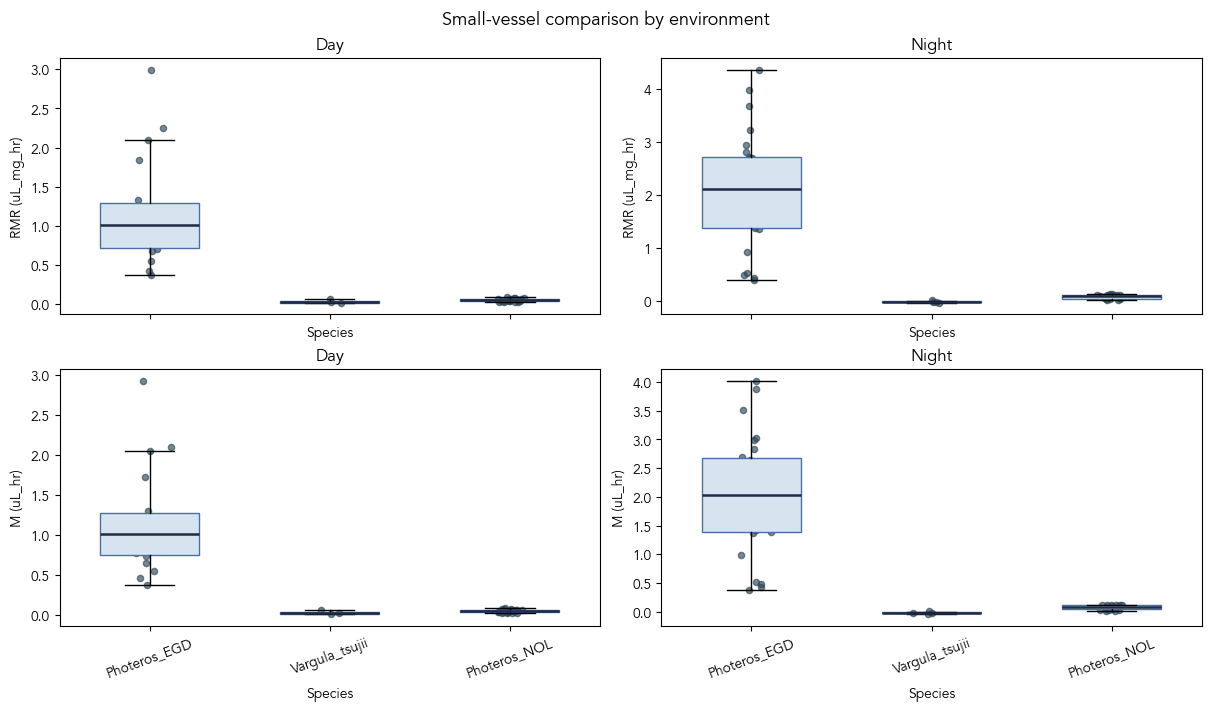

In [26]:
# Quick visualization: small vessels only, split by day/night
import matplotlib.pyplot as plt
import numpy as np

plot_df = compare_df.copy()
plot_df['species'] = pd.Categorical(plot_df['species'], categories=species_order, ordered=True)
plot_df['environment'] = pd.Categorical(plot_df['environment'], categories=env_order, ordered=True)

plt.rcParams['font.family'] = 'Avenir'
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True, sharex=True)

# Rows are metrics, columns are environments
metrics = [('RMR', 'RMR (uL_mg_hr)'), ('M', 'M (uL_hr)')]

for row_i, (metric, ylabel) in enumerate(metrics):
    for col_i, env in enumerate(env_order):
        ax = axes[row_i, col_i]
        env_df = plot_df[plot_df['environment'] == env]

        # Draw per-species box + jitter only where data exist.
        points_drawn = 0
        for x_i, sp in enumerate(species_order, start=1):
            y = env_df.loc[env_df['species'] == sp, metric].dropna().values
            if len(y) > 0:
                ax.boxplot(
                    [y],
                    positions=[x_i],
                    widths=0.55,
                    showfliers=False,
                    patch_artist=True,
                    boxprops={'facecolor': '#d6e4f0', 'edgecolor': '#4a6fa5'},
                    medianprops={'color': '#1f2a44', 'linewidth': 1.8},
                )
                jitter_x = np.random.normal(loc=x_i, scale=0.04, size=len(y))
                ax.scatter(jitter_x, y, alpha=0.65, s=20, color='#2f4858')
                points_drawn += len(y)

        ax.set_xticks(range(1, len(species_order) + 1))
        ax.set_xticklabels(species_order, rotation=20)
        ax.set_title(f'{env.capitalize()}')
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Species')

        if points_drawn == 0:
            ax.text(0.5, 0.5, 'No data yet', transform=ax.transAxes, ha='center', va='center', color='#666666')

fig.suptitle('Small-vessel comparison by environment', fontsize=13)
plt.show()

## EGD comparison by year and vessel

Diagnostic point plot of EGD RMR values loaded directly from `data/processed/batch_summary.csv`. Columns are grouped first by year (2025, then 2026) and then by vessel type. Points are jittered without summary boxes so the individual channel estimates remain visible. This cell can be run independently after a batch summary has been saved.

Loaded: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


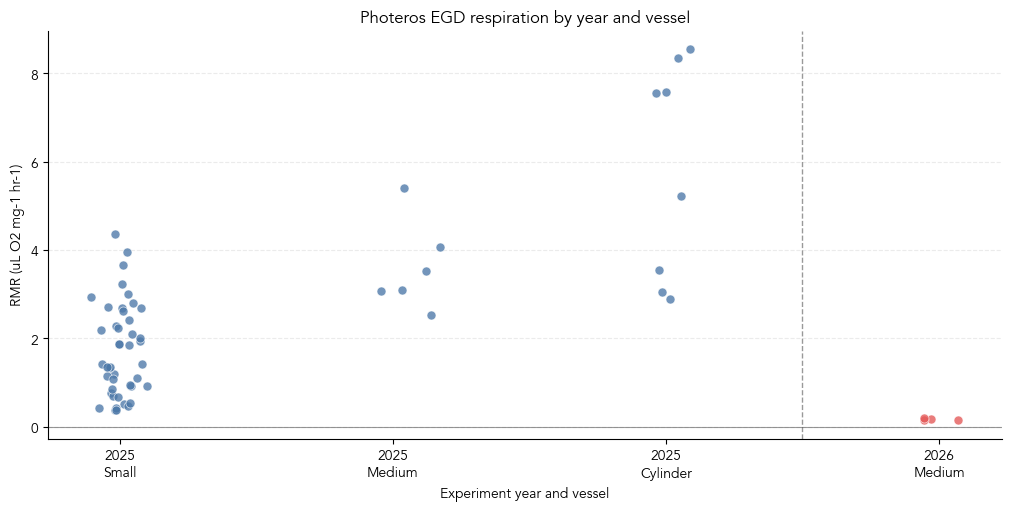

In [27]:
# EGD RMR comparison: 2025 vessel columns followed by 2026 vessel columns.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Load the saved aggregate directly so this cell does not depend on notebook state.
chart_start = Path.cwd().resolve()
chart_repo_root = next(
    candidate for candidate in (chart_start, *chart_start.parents)
    if (candidate / 'data' / 'processed' / 'batch_summary.csv').is_file()
)
batch_summary_path = chart_repo_root / 'data' / 'processed' / 'batch_summary.csv'
saved_batch_df = pd.read_csv(batch_summary_path)
print(f'Loaded: {batch_summary_path}')

if 'filtered' in saved_batch_df.columns:
    saved_batch_df['filtered'] = (
        saved_batch_df['filtered'].astype('string').str.lower()
        .map({'true': True, 'false': False, '1': True, '0': False})
        .fillna(False)
    )
    saved_batch_df = saved_batch_df.loc[saved_batch_df['filtered']].copy()

egd_plot_df = saved_batch_df.loc[saved_batch_df['species'].eq('Photeros_EGD')].copy()
egd_plot_df['year'] = (
    egd_plot_df['date'].astype('string').str.extract(r'(20\d{2})', expand=False)
)
egd_plot_df['RMR'] = pd.to_numeric(egd_plot_df['RMR'], errors='coerce')
egd_plot_df = egd_plot_df.dropna(subset=['year', 'vessel', 'RMR'])
egd_plot_df = egd_plot_df[egd_plot_df['year'].isin(['2025', '2026'])]

vessel_order = ['small', 'medium', 'cylinder', 'large']
category_order = [
    (year, vessel)
    for year in ['2025', '2026']
    for vessel in vessel_order
    if ((egd_plot_df['year'] == year) & (egd_plot_df['vessel'] == vessel)).any()
]

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
rng = np.random.default_rng(2026)  # reproducible jitter
year_colors = {'2025': '#4c78a8', '2026': '#e45756'}

for x_pos, (year, vessel) in enumerate(category_order):
    values = egd_plot_df.loc[
        (egd_plot_df['year'] == year) & (egd_plot_df['vessel'] == vessel),
        'RMR',
    ].to_numpy()
    jittered_x = rng.normal(loc=x_pos, scale=0.055, size=len(values))
    ax.scatter(
        jittered_x, values, s=42, alpha=0.78,
        color=year_colors[year], edgecolor='white', linewidth=0.5, zorder=3,
    )

# Visually separate the final 2025 column from the first 2026 column.
n_2025_columns = sum(year == '2025' for year, _ in category_order)
if 0 < n_2025_columns < len(category_order):
    ax.axvline(n_2025_columns - 0.5, color='#999999', linewidth=1, linestyle='--')

ax.axhline(0, color='#555555', linewidth=0.8, alpha=0.6)
ax.set_xticks(range(len(category_order)))
ax.set_xticklabels([f'{year}\n{vessel.title()}' for year, vessel in category_order])
ax.set_xlabel('Experiment year and vessel')
ax.set_ylabel('RMR (uL O2 mg-1 hr-1)')
ax.set_title('Photeros EGD respiration by year and vessel')
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.show()